# Assignment 3: Autonomous Driving (Part 2)


In this assignment, you will continue from **Assignment 2: Autonomous Driving (Part 1)**. You should already have collected a Car Racing dataset, saved it as `.npz`, written a `metadata.json` action mapping, and implemented a PyTorch-compatible data loading pipeline.

The goal of this assignment is therefore **not** to collect or prepare the dataset again. Instead, you will use your existing dataset pipeline to train a convolutional neural network (CNN) controller, compare several training settings, and finally run the trained controller in the Gymnasium simulator.

The learning problem is treated as **imitation learning**: the model receives an image observation from the Car Racing environment and predicts the discrete action demonstrated by the human driver during data collection.

**Note:** All scripts must be executable on **any** machine with the required libraries installed. Assignment solutions may be submitted either as Jupyter notebooks or `.py` files. Visual results may be submitted as part of the notebook, a PDF, or image files. When submitting multiple files, create a zip archive that contains all submissions.


## Task 1: Reuse the Dataset Pipeline From Assignment 2

In Assignment 2, you generated the dataset and implemented the PyTorch data pipeline. In this task, you will connect that existing work to the training experiments below.

Do **not** repeat the data collection task here. Adapt the scaffold below using your **finished Assignment 2 code**.

Use one fixed split for all experiments:

- 60% consecutive training samples
- 20% consecutive validation samples
- 20% consecutive test samples

The dataset must not be shuffled before splitting. The training loader may shuffle mini-batches after the split has been created.

### What you need to do

1. Load the `.npz` dataset and `metadata.json` generated in Assignment 2.
2. Create train, validation, and test loaders using the fixed consecutive split.
3. Print the split sizes and inspect one mini-batch shape.
4. Keep this same split for all following experiments.

**Task Output:** Fixed split indices and train/validation/test data loaders.

Train samples: 3000
Validation samples: 1000
Test samples: 1000
torch.Size([64, 3, 96, 96])
torch.Size([64, 5])


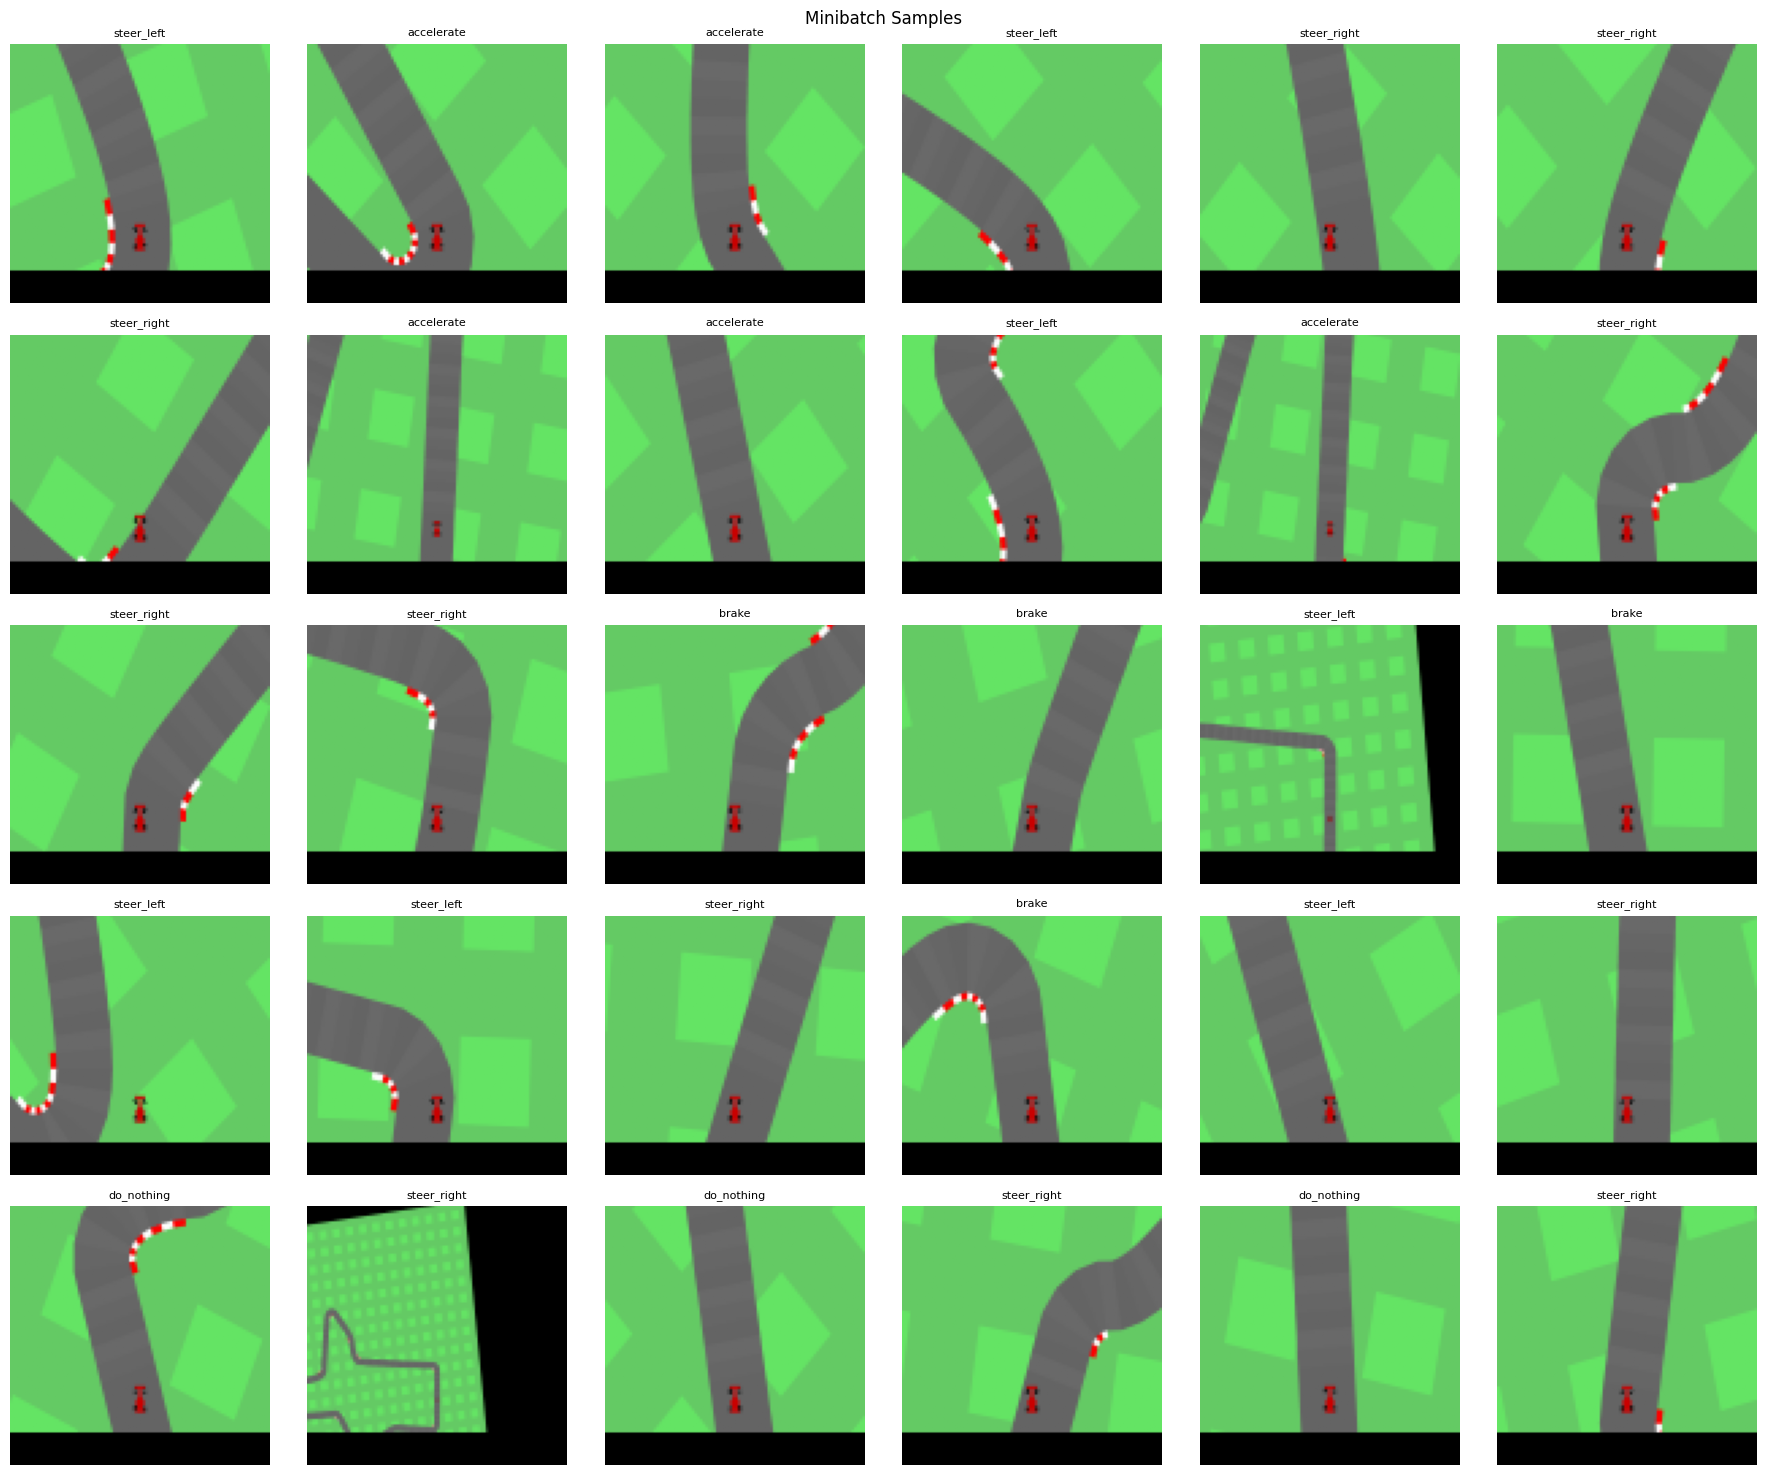

In [18]:
from pathlib import Path
import json
import random
import copy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 64
NUM_CLASSES = 5
MAX_EPOCHS = 30

DATA_DIR = Path("../Assignment_2/data") 
DATASET_PATH = DATA_DIR / "dataset.npz"
METADATA_PATH = DATA_DIR / "metadata.json"

# TODO: load images, labels, and metadata from the files generated in Assignment 2
data = np.load(DATASET_PATH)
images = data["images"]
labels = data["labels"]
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

if "action_mapping" in metadata:
    action_mapping = metadata["action_mapping"]

# TODO: define or infer the action indices needed for label updates during augmentation
LEFT_ACTION = action_mapping["2"]
RIGHT_ACTION = action_mapping["1"]

# TODO: create a consecutive 60/20/20 split
# TODO [optional] split long recordings into shorter clips to increase the number of samples
import numpy as np

n = len(images)
indices = np.arange(n)

np.random.seed(SEED)
np.random.shuffle(indices)

n_train = int(0.6 * n)
n_val = int(0.2 * n)

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train + n_val]
test_indices = indices[n_train + n_val:]

print(f"Train samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")

# TODO: use the dataset class from Assignment 2
class CarRacingDataset(Dataset):
    def __init__(
        self,
        data_dir,
        indices,
        horizontal_flip=False,
        flip_prob=0.5,
        gaussian_noise=False,
        noise_prob=0.5,
        noise_std=0.03,
        brown_road=False,
        brown_prob=0.5,
        blackout_hud=False,
    ):
        path = Path(data_dir)

        # Allows "dataset.npz" and Folder
        if path.is_dir(): # For directories
            data_path = path / "dataset.npz"
            meta_path = path / "metadata.json"
        else: # For explicit link to data
            data_path = path 
            meta_path = path.with_name("metadata.json")

        with np.load(data_path) as data:
            self.images = data["images"].copy() # Load images without changing dataset
            self.labels = data["labels"].astype(np.float32).copy() # Preperation for PyTorch

        self.indices = indices
        self.horizontal_flip = horizontal_flip
        self.flip_prob = flip_prob
        self.gaussian_noise = gaussian_noise
        self.noise_prob = noise_prob
        self.noise_std = noise_std
        self.brown_road = brown_road
        self.brown_prob = brown_prob

        self.blackout_hud = blackout_hud # Hide HUD so that model doesn't learn from HUD

        # Load action names from metadata.json
        if meta_path.exists():
            with open(meta_path, "r", encoding="utf-8") as f: # Read mode
                metadata = json.load(f)

            action_mapping = metadata.get("action_mapping", None)
            if isinstance(action_mapping, dict):
                parsed_names = []
                for i in range(5):
                    if str(i) in action_mapping:
                        parsed_names.append(action_mapping[str(i)]) # json saves indices/keys as string
                    elif i in action_mapping: # If no keys can be found
                        parsed_names.append(action_mapping[i])
                    else:
                        print("Error loading Action names from metadata.json")
                self.action_names = parsed_names

    def __len__(self):
        return len(self.indices)
    
    @staticmethod
    def _flip_label_left_right(label): # Needed wenn image will be flipped horizontally
        """
        Change one hot labels for:
        1 = steer_left
        2 = steer_right
        """
        label = label.copy()
        label[[1, 2]] = label[[2, 1]]
        return label
    
    @staticmethod
    def _change_road_to_brown(image):
        """
        Simple heuristics:
        Gray Street pixels will be colored in brown
        """
        img = image.astype(np.float32).copy() # Change to float32 to avoid overflow

        r = img[..., 0]
        g = img[..., 1]
        b = img[..., 2]

        # Gray pixels: Channels similiar and mean intensity
        gray_mask = (
            (np.abs(r - g) < 15)
            & (np.abs(g - b) < 15)
            & (r > 60)
            & (r < 200)
        )

        # Calculate mean brightness of pixels
        brightness = img.mean(axis=-1, keepdims=True) / 255.0
        brown_base = np.array([150.0, 100.0, 60.0], dtype=np.float32).reshape(
            1, 1, 3
        )
        #Apply brown colour without changing brightness of pixels
        brown_img = np.clip((0.45 + 0.55 * brightness) * brown_base, 0, 255)

        img[gray_mask] = brown_img[gray_mask]
        return img.astype(np.uint8)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image = self.images[real_idx].copy()
        label = self.labels[real_idx].copy()

        # Hide HUD
        if self.blackout_hud:
            image[-10:, :, :] = 0

        # 1) Horizontal flip
        if self.horizontal_flip and np.random.rand() < self.flip_prob:
            image = np.ascontiguousarray(np.fliplr(image)) # NumPy.FlipLeftRight(image), np.ascontiguousarray preserves array from changes
            label = self._flip_label_left_right(label) # Flip label 

        # 2) Change street color
        if self.brown_road and np.random.rand() < self.brown_prob:
            image = self._change_road_to_brown(image)

        # Change to float float [0, 1] 
        image = image.astype(np.float32) / 255.0

        # 3) Gaussian noise
        if self.gaussian_noise and np.random.rand() < self.noise_prob:
            noise = np.random.normal(
                loc=0.0,
                scale=self.noise_std,
                size=image.shape,
            ).astype(np.float32)
            image = np.clip(image + noise, 0.0, 1.0)

        # HxWxC -> CxHxW for PyTorch
        image = torch.from_numpy(np.transpose(image, (2, 0, 1))).float()
        label = torch.from_numpy(label).float()

        return image, label


# TODO: create train/validation/test datasets and data loaders
train_dataset =  CarRacingDataset( # Dataset with augmentation
    data_dir=DATA_DIR,
    indices=train_indices,
    horizontal_flip=False,
    flip_prob=0.5,
    gaussian_noise=False,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=False,
    brown_prob=0.5,
    blackout_hud=True,
)


val_dataset = CarRacingDataset( # Dataset with augmentation
    data_dir=DATA_DIR,
    indices=val_indices,
    horizontal_flip=False,
    flip_prob=0.5,
    gaussian_noise=False,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=False,
    brown_prob=0.5,
    blackout_hud=True,
)

test_dataset = CarRacingDataset( # Dataset with augmentation
    data_dir=DATA_DIR,
    indices=test_indices,
    horizontal_flip=False,
    flip_prob=0.5,
    gaussian_noise=False,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=False,
    brown_prob=0.5,
    blackout_hud=True,
)

train_loader  = DataLoader( # Dataloader
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader( # Dataloader
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader( # Dataloader
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# TODO: inspect one mini-batch
batch_images, batch_labels = next(iter(train_loader))

print(batch_images.shape)
print(batch_labels.shape)

def visualize_samples(dataset, n=30, title="Minibatch Samples"):
    n = min(n, len(dataset))
    cols = 6
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i in range(n):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()
        action_idx = int(torch.argmax(label).item())
        action_name = dataset.action_names[action_idx]

        axes[i].imshow(image_np)
        axes[i].set_title(action_name, fontsize=8)
        axes[i].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_samples(dataset=train_dataset)



## Task 2: Define a CNN Driving Model

In this task, you will define a convolutional neural network that predicts the driving action from an input frame.

You may choose the exact architecture, but your model must include:

- at least **2 convolutional layers**,
- at least **1 linear layer**,
- ReLU activations or another clearly justified non-linearity,
- an output layer with **5 logits**, one for each action class.

Use `torch.nn.CrossEntropyLoss` during training. Do not apply `softmax` inside the model when using `CrossEntropyLoss`, because the loss function expects raw logits.

### What you need to do

1. Implement the CNN model.
2. Verify that one mini-batch passes through the model.
3. Print the output tensor shape and the number of trainable parameters.

**Task Output:** A PyTorch CNN model for Car Racing action classification.


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class CarRacingCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=5):
        super().__init__()

        # TODO: design your CNN architecture
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



# TODO: instantiate the model and verify that one mini-batch passes through it
model = CarRacingCNN(in_channels=3, num_classes=5).to(device)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

logits = model(images)

print("Output shape:", logits.shape)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Using device: cuda
Output shape: torch.Size([64, 5])
Trainable parameters: 103365


## Task 3: Train the Baseline Model

In this task, you will train the CNN on the fixed split from Task 1. This is the baseline experiment, so no augmentation should be enabled.

Use early stopping with:

- `min_delta = 0.0`
- `patience = 3`

Track the loss and accuracy for the training, validation, and test subsets.\
The test set should only be used for evaluation, not for choosing the best model or tuning hyperparameters.

### What you need to do

1. Implement one training epoch.
2. Implement evaluation without gradient computation.
3. Implement early stopping based on validation loss.
4. Save the model parameters with the best validation loss.
5. Plot loss and accuracy over time.
6. Report optimizer, learning rate, batch size, number of epochs run, and final test performance.

**Task Output:** Training curves and test-set loss/accuracy for the baseline model.


Using device: cuda
Epoch 01/30 | train loss 1.6107, train acc 0.1980 | val loss 1.6113, val acc 0.1880
Epoch 02/30 | train loss 1.6099, train acc 0.2070 | val loss 1.6109, val acc 0.1880
Epoch 03/30 | train loss 1.6081, train acc 0.2093 | val loss 1.6064, val acc 0.1880
Epoch 04/30 | train loss 1.5886, train acc 0.2463 | val loss 1.5623, val acc 0.2500
Epoch 05/30 | train loss 1.5563, train acc 0.2863 | val loss 1.5494, val acc 0.2740
Epoch 06/30 | train loss 1.5473, train acc 0.2963 | val loss 1.5415, val acc 0.2670
Epoch 07/30 | train loss 1.5246, train acc 0.3050 | val loss 1.5149, val acc 0.3000
Epoch 08/30 | train loss 1.4944, train acc 0.2967 | val loss 1.5031, val acc 0.3090
Epoch 09/30 | train loss 1.4761, train acc 0.3160 | val loss 1.4570, val acc 0.2950
Epoch 10/30 | train loss 1.4085, train acc 0.3657 | val loss 1.3835, val acc 0.3590
Epoch 11/30 | train loss 1.3797, train acc 0.3853 | val loss 1.4259, val acc 0.3850
Epoch 12/30 | train loss 1.3356, train acc 0.4270 | val l

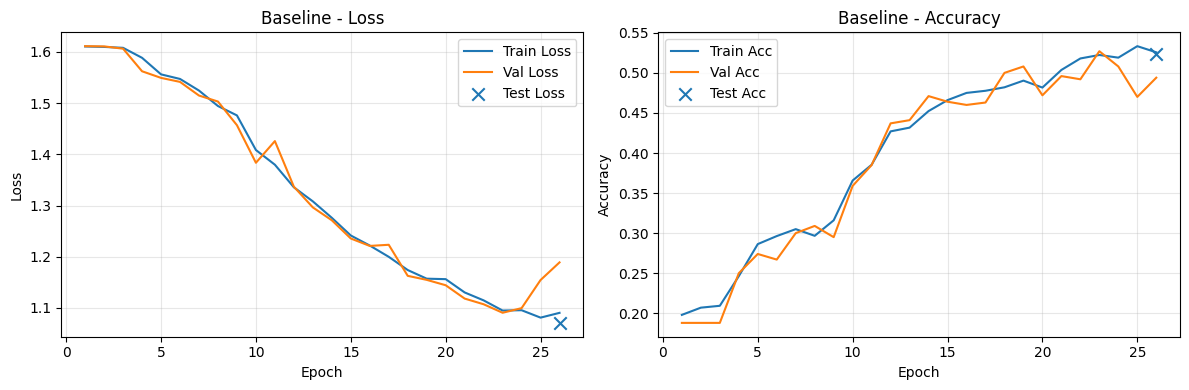

Baseline test loss / accuracy: (1.0707171926498413, 0.523)
Optimizer: Adam
Learning rate: 0.001
Batch size: 64
Epochs run: 26


In [ ]:
from copy import deepcopy

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if labels.ndim == 2:
            labels = labels.argmax(dim=1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if labels.ndim == 2:
            labels = labels.argmax(dim=1)


        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


def fit_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    device,
    max_epochs=30,
    min_delta=0.0,
    patience=3,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_loss = float("inf")
    best_state = deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{max_epochs} | "
            f"train loss {train_loss:.4f}, train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f}, val acc {val_acc:.4f}"
        )

        # Early stopping based on validation loss
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping triggered after {epoch + 1} epochs. "
                f"Best val loss: {best_val_loss:.4f}"
            )
            break

    # Load best model
    model.load_state_dict(best_state)

    # Final test evaluation only once
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    return model, history, (test_loss, test_acc)


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")

    # Optional: last test point as marker only
    if "test_loss" in history:
        axes[0].scatter(
            [len(epochs)],
            [history["test_loss"]],
            label="Test Loss",
            marker="x",
            s=80,
        )

    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")

    if "test_acc" in history:
        axes[1].scatter(
            [len(epochs)],
            [history["test_acc"]],
            label="Test Acc",
            marker="x",
            s=80,
        )

    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# TODO: train the baseline model without augmentation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

baseline_model = CarRacingCNN(in_channels=3, num_classes=5).to(device)

criterion = nn.CrossEntropyLoss() #log(5) ca 1.61
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

baseline_model, baseline_history, baseline_test = fit_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    max_epochs=30,
    min_delta=0.0,
    patience=3,
)

baseline_history["test_loss"] = baseline_test[0]
baseline_history["test_acc"] = baseline_test[1]

plot_history(baseline_history, "Baseline")
print("Baseline test loss / accuracy:", baseline_test)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Batch size:", train_loader.batch_size)
print("Epochs run:", len(baseline_history["train_loss"]))

## Task 4: Train With the Assignment 2 Augmentation Pipeline

In Assignment 2, you implemented optional data augmentation in the data loading pipeline.\
In this task, you will use that existing augmentation functionality as a training experiment.

Do **not** create augmented copies of the dataset on disk. Augmentations must be applied dynamically while loading mini-batches.\
Use the same train/validation/test split as in Task 1 and apply augmentation only to the training subset.

If your Assignment 2 augmentation code includes horizontal flipping, remember that steering labels must be updated when an image is flipped.

### What you need to do

1. Enable the augmentation options from your Assignment 2 data loader for the training subset.
2. Keep validation and test loaders unaugmented.
3. Train a new model with the same model architecture and training settings as the baseline.
4. Compare loss and accuracy with and without augmentation in the same figure.

**Task Output:** Augmented training curves, test-set loss/accuracy, and comparison plot.


Epoch 01/30 | train loss 1.6109, train acc 0.1853 | val loss 1.6101, val acc 0.1840
Epoch 02/30 | train loss 1.6099, train acc 0.1993 | val loss 1.6092, val acc 0.2120
Epoch 03/30 | train loss 1.6095, train acc 0.2033 | val loss 1.6086, val acc 0.1920
Epoch 04/30 | train loss 1.6030, train acc 0.2410 | val loss 1.5824, val acc 0.3030
Epoch 05/30 | train loss 1.5325, train acc 0.3063 | val loss 1.4813, val acc 0.3180
Epoch 06/30 | train loss 1.4913, train acc 0.3480 | val loss 1.4392, val acc 0.3740
Epoch 07/30 | train loss 1.4412, train acc 0.3767 | val loss 1.4292, val acc 0.3720
Epoch 08/30 | train loss 1.3841, train acc 0.3973 | val loss 1.3361, val acc 0.4300
Epoch 09/30 | train loss 1.3475, train acc 0.4160 | val loss 1.3026, val acc 0.4200
Epoch 10/30 | train loss 1.2825, train acc 0.4380 | val loss 1.2635, val acc 0.4130
Epoch 11/30 | train loss 1.2560, train acc 0.4420 | val loss 1.2347, val acc 0.4550
Epoch 12/30 | train loss 1.2183, train acc 0.4597 | val loss 1.2015, val acc

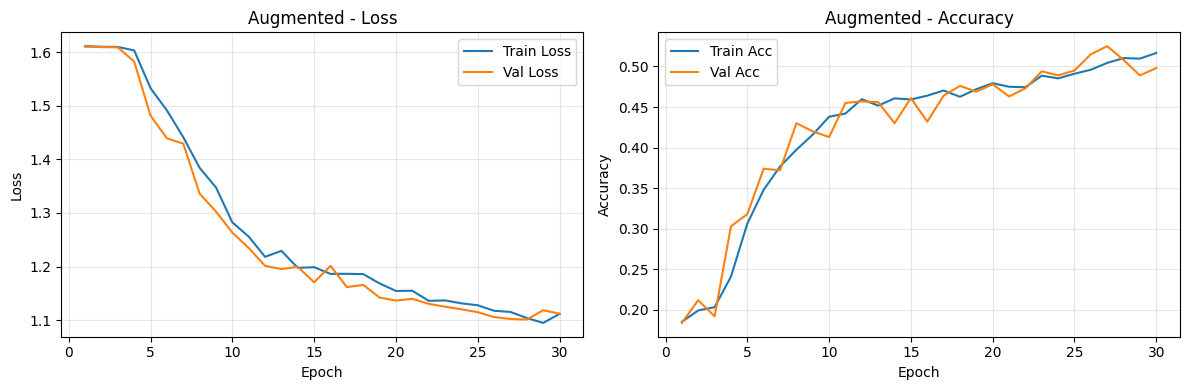

Augmented test loss / accuracy: (1.107410011291504, 0.482)


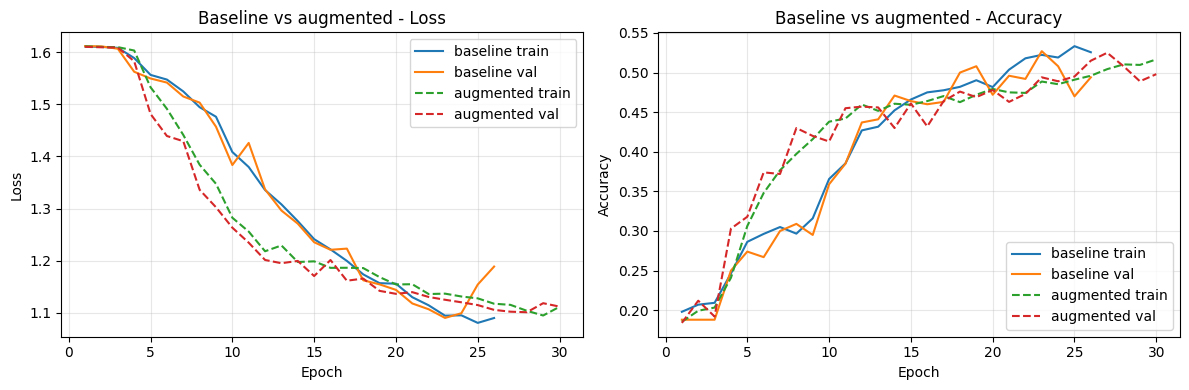

In [19]:
# TODO: create an augmented training dataset using dynamic augmentation only for training
augmented_train_dataset = CarRacingDataset(
    data_dir=DATA_DIR,
    indices=train_indices,
    horizontal_flip=True,
    flip_prob=0.5,
    gaussian_noise=True,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=True,
    brown_prob=0.5,
    blackout_hud=True,
)

augmented_val_dataset = augmented_val_dataset = CarRacingDataset(
    data_dir=DATA_DIR,
    indices=val_indices,
    horizontal_flip=False,
    gaussian_noise=False,
    brown_road=False,
    blackout_hud=True,
)

augmented_test_dataset = augmented_test_dataset = CarRacingDataset(
    data_dir=DATA_DIR,
    indices=test_indices,
    horizontal_flip=False,
    gaussian_noise=False,
    brown_road=False,
    blackout_hud=True,
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

augmented_val_loader = augmented_val_loader = DataLoader(
    augmented_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

augmented_test_loader = DataLoader(
    augmented_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# TODO: train a second model with augmentation enabled
augmented_model = CarRacingCNN(in_channels=3, num_classes=NUM_CLASSES).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(augmented_model.parameters(), lr=1e-3)

augmented_model, augmented_history, augmented_test = fit_model(
    model=augmented_model,
    train_loader=augmented_train_loader,
    val_loader=augmented_val_loader,
    test_loader=augmented_test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    max_epochs=MAX_EPOCHS,
    min_delta=0.0,
    patience=3,
)

plot_history(augmented_history, "Augmented")
print("Augmented test loss / accuracy:", augmented_test)


def plot_experiment_comparison(history_a, history_b, label_a, label_b, title):
    # TODO: compare loss and accuracy curves for two experiments
    epochs_a = range(1, len(history_a["train_loss"]) + 1)
    epochs_b = range(1, len(history_b["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    axes[0].plot(
        epochs_a,
        history_a["train_loss"],
        label=f"{label_a} train",
    )
    axes[0].plot(
        epochs_a,
        history_a["val_loss"],
        label=f"{label_a} val",
    )
    axes[0].plot(
        epochs_b,
        history_b["train_loss"],
        label=f"{label_b} train",
        linestyle="--",
    )
    axes[0].plot(
        epochs_b,
        history_b["val_loss"],
        label=f"{label_b} val",
        linestyle="--",
    )
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Accuracy plot
    axes[1].plot(
        epochs_a,
        history_a["train_acc"],
        label=f"{label_a} train",
    )
    axes[1].plot(
        epochs_a,
        history_a["val_acc"],
        label=f"{label_a} val",
    )
    axes[1].plot(
        epochs_b,
        history_b["train_acc"],
        label=f"{label_b} train",
        linestyle="--",
    )
    axes[1].plot(
        epochs_b,
        history_b["val_acc"],
        label=f"{label_b} val",
        linestyle="--",
    )
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_experiment_comparison(baseline_history, augmented_history, "baseline", "augmented", "Baseline vs augmented")


## Task 5: Offline Error Analysis

Before running the trained controllers in simulation, analyze how well each model predicts each action class.

Overall accuracy can be misleading if the dataset is imbalanced. In this task, evaluate whether the models are learning all driving actions or mainly predicting the most frequent class.

### What you need to do

1. Plot the action distribution for the train, validation, and test splits, in a single bar plot.
2. Compute a majority-class baseline accuracy on the test set.
3. Compute and display a confusion matrix for the baseline and augmented models.
4. Report per-class accuracy, precision, recall, or F1-score.
5. Briefly discuss which actions are most often confused.

**Task Output:** Action distribution plots, majority-class baseline, confusion matrices, and per-class metrics.

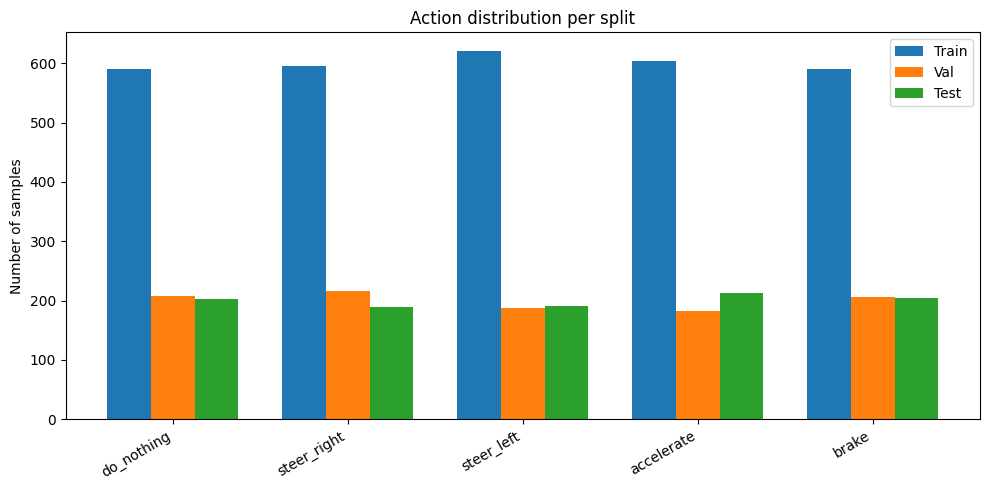

Majority class: steer_left
Majority-class test accuracy: 0.191

Baseline Model
--------------
Accuracy: 0.5230


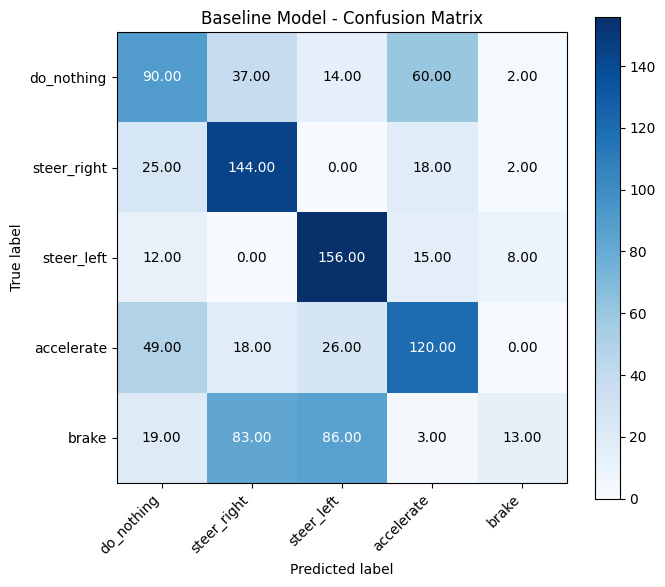

Class            Precision     Recall         F1    Support
------------------------------------------------------------
do_nothing          0.4615     0.4433     0.4523        203
steer_right         0.5106     0.7619     0.6115        189
steer_left          0.5532     0.8168     0.6596        191
accelerate          0.5556     0.5634     0.5594        213
brake               0.5200     0.0637     0.1135        204

Augmented Model
---------------
Accuracy: 0.4820


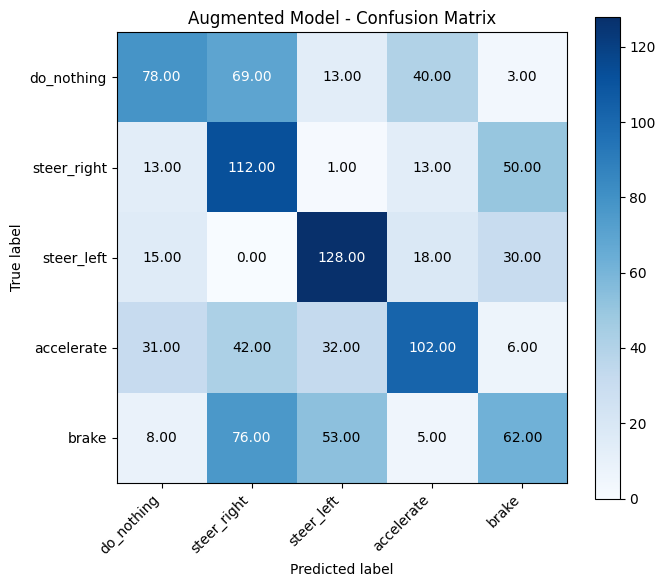

Class            Precision     Recall         F1    Support
------------------------------------------------------------
do_nothing          0.5379     0.3842     0.4483        203
steer_right         0.3746     0.5926     0.4590        189
steer_left          0.5639     0.6702     0.6124        191
accelerate          0.5730     0.4789     0.5217        213
brake               0.4106     0.3039     0.3493        204


In [23]:
# TODO: Visualize and compute model metrics
class_names = [action_mapping[str(i)] for i in range(NUM_CLASSES)]

def labels_to_class_indices(labels):
    if torch.is_tensor(labels):
        if labels.ndim == 2:
            return labels.argmax(dim=1)
        return labels
    labels = np.asarray(labels)
    if labels.ndim == 2:
        return labels.argmax(axis=1)
    return labels


def collect_true_labels(loader):
    all_labels = []
    for _, labels in loader:
        labels = labels_to_class_indices(labels)
        all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_labels, axis=0)


def collect_predictions(model, loader, device):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())

    return np.concatenate(all_preds, axis=0)


def plot_action_distribution(train_loader, val_loader, test_loader, class_names):
    y_train = collect_true_labels(train_loader)
    y_val = collect_true_labels(val_loader)
    y_test = collect_true_labels(test_loader)

    n_classes = len(class_names)
    train_counts = np.bincount(y_train, minlength=n_classes)
    val_counts = np.bincount(y_val, minlength=n_classes)
    test_counts = np.bincount(y_test, minlength=n_classes)

    x = np.arange(n_classes)
    width = 0.25

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_counts, width=width, label="Train")
    plt.bar(x, val_counts, width=width, label="Val")
    plt.bar(x + width, test_counts, width=width, label="Test")

    plt.xticks(x, class_names, rotation=30, ha="right")
    plt.ylabel("Number of samples")
    plt.title("Action distribution per split")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return train_counts, val_counts, test_counts


def majority_class_baseline_accuracy(train_loader, test_loader):
    y_train = collect_true_labels(train_loader)
    y_test = collect_true_labels(test_loader)

    counts = np.bincount(y_train)
    majority_class = counts.argmax()
    test_acc = (y_test == majority_class).mean()

    return majority_class, test_acc

def compute_confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def plot_confusion_matrix(cm, class_names, title, normalize=False):
    cm_plot = cm.astype(np.float32)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm_plot / row_sums

    plt.figure(figsize=(7, 6))
    im = plt.imshow(cm_plot, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im)

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    fmt = ".2f"
    thresh = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0.5

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            plt.text(
                j,
                i,
                format(cm_plot[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm_plot[i, j] > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

def classification_metrics_from_cm(cm):
    n_classes = cm.shape[0]
    metrics = []

    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )
        support = cm[c, :].sum()

        metrics.append((precision, recall, f1, support))

    return metrics


def print_classification_report(cm, class_names):
    metrics = classification_metrics_from_cm(cm)

    print(
        f"{'Class':<15} {'Precision':>10} {'Recall':>10} "
        f"{'F1':>10} {'Support':>10}"
    )
    print("-" * 60)

    for name, (precision, recall, f1, support) in zip(class_names, metrics):
        print(
            f"{name:<15} {precision:10.4f} {recall:10.4f} "
            f"{f1:10.4f} {support:10d}"
        )

    return metrics

def evaluate_model_offline(model, loader, device, class_names, title):
    y_true = collect_true_labels(loader)
    y_pred = collect_predictions(model, loader, device)

    acc = (y_true == y_pred).mean()
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Accuracy: {acc:.4f}")

    cm = compute_confusion_matrix(y_true, y_pred, n_classes=len(class_names))
    plot_confusion_matrix(cm, class_names, f"{title} - Confusion Matrix")
    print_classification_report(cm, class_names)

    return y_true, y_pred, cm, acc

plot_action_distribution(train_loader, val_loader, test_loader, class_names)

majority_class, majority_test_acc = majority_class_baseline_accuracy(
    train_loader, test_loader
)
print("Majority class:", class_names[int(majority_class)])
print("Majority-class test accuracy:", majority_test_acc)

baseline_y_true, baseline_y_pred, baseline_cm, baseline_acc = (
    evaluate_model_offline(
        baseline_model,
        test_loader,
        device,
        class_names,
        "Baseline Model",
    )
)

aug_y_true, aug_y_pred, aug_cm, aug_acc = evaluate_model_offline(
    augmented_model,
    augmented_test_loader,
    device,
    class_names,
    "Augmented Model",
)

# TODO: add your written discussion in a markdown cell below

**Brief Discussion:**
The augmented model improves the detection of the brake class substantially compared to the baseline, as shown by its much higher recall and F1-score. However, this improvement comes at the cost of weaker performance on the other classes, especially do_nothing and steer_right. Overall, augmentation helps with the rare/difficult braking action, but it does not improve the model uniformly across all classes.

## Task 6: Training Set Outlier Detection

Use the trained model to identify unusual or difficult training examples.

For each training sample, compute the model's cross-entropy loss and prediction confidence.\
Samples with high loss or low confidence may indicate mislabeled data, ambiguous driving situations, rare actions, or visually unusual states.

We define the model confidence as the highest softmax probability assigned to any action class $c$:

$
\text{confidence} = \max_c p_c
$

### What you need to do

1. Run the trained model on the training dataset without augmentation.
2. Select the top-10 highest-loss samples.
3. Visualize these samples together with:
   - true action
   - predicted action
   - model confidence
   - loss value
4. Briefly discuss whether these examples look like errors, rare situations, or useful hard examples.

**Task Output:** A visualization of the most difficult training samples and a short interpretation.

In [ ]:
# TODO: find and visualize some failure cases for both models

# TODO: add your written interpretation in a markdown cell below

**Short Interpretation:** \<Your Answer\>

## Task 7: Run the Trained Controller in Simulation

In this task, you will use the trained CNN as a controller inside the Gymnasium Car Racing environment.\
At each time step, the model receives the current image observation and predicts one of the five discrete actions.

We want to initialize the simulation with three different seeds to observe the variance of our controller.

### What you need to do

Repeat for three different seeds:
1. Create `CarRacing-v3` with `continuous=False`.
2. Convert each simulator observation into a model input tensor.
3. Predict an action with the trained model.
4. Step the environment using the predicted action.
5. Run at least one complete episode or a fixed maximum number of steps for each trained policy.
6. Report the total reward for each policy.
7. Display a video that shows the baseline and augmented policies driving in simulation next to each other.

Remember that high offline accuracy does not always guarantee stable closed-loop driving.

**Task Output:** Inference code, and for three different seeds: total episode rewards & side-by-side comparison video.


In [ ]:
@torch.no_grad()
def predict_action(model, observation, device):
    # TODO: preprocess one simulator observation and predict one discrete action
    return ...


def rollout_action(model_action, step, frame_deltas, warmup_steps=25, stuck_window=12, stuck_delta=0.001):
    # TODO: optionally add rollout-only warm-start or stuck-recovery logic
    return model_action


def run_policy_rollout(model, name, seed=SEED, max_steps=1000):
    # TODO: create the CarRacing environment and run one closed-loop episode
    return {
        "name": name,
        "frames": ...,
        "reward": ...,
        "episode_length": ...,
    }


policies = [
    {"name": "baseline RGB", "model": baseline_model},
    {"name": "augmented RGB", "model": augmented_model},
]

# TODO: run both policies, save individual rollout videos, and save one side-by-side comparison video



## Task 8: Final Comparison and Discussion

Summarize your results across all experiments.

### What you need to report

1. Baseline RGB model test loss and accuracy.
2. Augmented RGB model test loss and accuracy.
3. Closed-loop simulator reward for each trained controller.
4. A short explanation of which model worked best and why.
5. A short discussion of limitations, for example class imbalance, correlated frames, distribution shift, or compounding errors during closed-loop driving.
6. A short explanation why training with augmentations might not provide the best performance in this case. 

**Task Output:** Final result table and concise written discussion.

In [ ]:
# TODO: collect your final numbers in a table

# TODO: add your written discussion in a markdown cell below

### Discussion

**Answer:** \<Your Answer\>
